In [1]:
import numpy
import ot
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_2d_gaussian_samples(mean, std, num_samples):
    mean = np.array(mean).reshape(2)
    if np.isscalar(std):
        cov = np.eye(2) * std**2
    else:
        cov = np.diag(np.array(std)**2)
    
    samples = np.random.multivariate_normal(mean, cov, num_samples)
    return samples

In [27]:
mean_a = [0, 0]
std_a = [5.0, 1.0]
num_samples_a = 20
samples_A = generate_2d_gaussian_samples(mean_a, std_a, num_samples_a)

mean_b = [10, 10]
std_b = [1.0, 2.0]
num_samples_b = 20
samples_B = generate_2d_gaussian_samples(mean_b, std_b, num_samples_b)

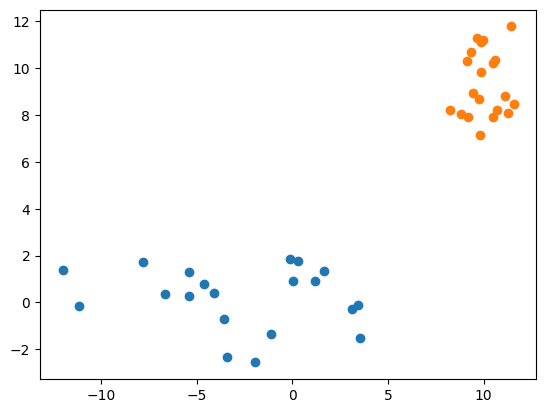

In [28]:
plt.scatter(samples_A[:, 0], samples_A[:, 1])
plt.scatter(samples_B[:, 0], samples_B[:, 1])

In [29]:
mu = np.array([1.0 / num_samples_a] * num_samples_a)
nu = np.array([1.0 / num_samples_b] * num_samples_b)

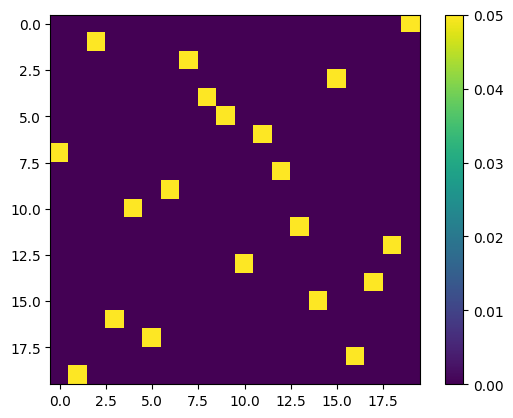

In [30]:
P = ot.emd(a=mu, b=nu, M=ot.dist(samples_A, samples_B))
plt.imshow(P)
plt.colorbar()
plt.show()

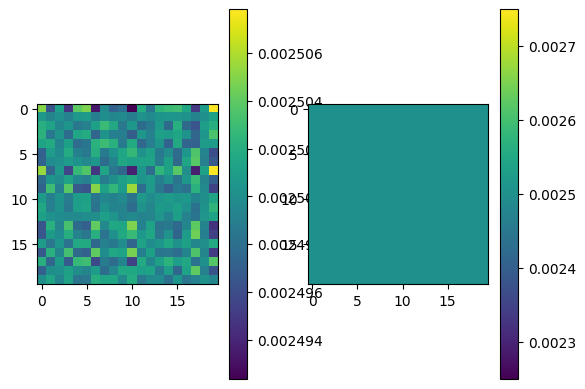

In [38]:
P_sinkhorn = ot.sinkhorn(mu, nu, ot.utils.dist(samples_A, samples_B), reg=10000.0)
plt.subplot(1, 2, 1)
plt.imshow(P_sinkhorn)
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(np.outer(mu, nu))
plt.colorbar()
plt.show()

In [7]:
n_samples = num_samples_a + num_samples_b
barycenter = ot.bregman.free_support_sinkhorn_barycenter(
    measures_locations=[samples_A, samples_B],
    measures_weights=[mu, nu],
    reg=1e-3,
    verbose=True,
    X_init=np.random.randn(n_samples, 2),
    b=np.array([1.0 / n_samples] * n_samples),
    method='sinkhorn_log'
)

iteration %d, displacement_square_norm=%f
 0 2019.4050387390525
iteration %d, displacement_square_norm=%f
 1 209.11525955252802
iteration %d, displacement_square_norm=%f
 2 78.44035667638772


/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


iteration %d, displacement_square_norm=%f
 3 9.205011937026311
iteration %d, displacement_square_norm=%f
 4 0.6265379470689809
iteration %d, displacement_square_norm=%f
 5 3.0155801821900514
iteration %d, displacement_square_norm=%f
 6 0.2330382340362366
iteration %d, displacement_square_norm=%f
 7 0.22229625897652056
iteration %d, displacement_square_norm=%f
 8 0.20362341031975767
iteration %d, displacement_square_norm=%f
 9 0.0334346837737292
iteration %d, displacement_square_norm=%f
 10 0.0077096988901148595
iteration %d, displacement_square_norm=%f
 11 2.048162457629587e-07
iteration %d, displacement_square_norm=%f
 12 5.656089467330836e-17


In [8]:
barycenter.shape

(45, 2)

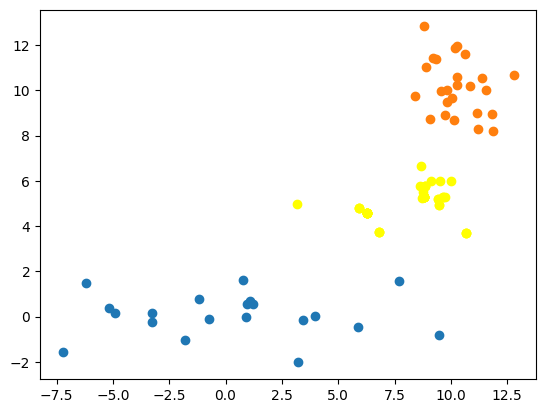

In [9]:
plt.scatter(barycenter[:, 0], barycenter[:, 1], c='yellow')
plt.scatter(samples_A[:, 0], samples_A[:, 1])
plt.scatter(samples_B[:, 0], samples_B[:, 1])
plt.show()

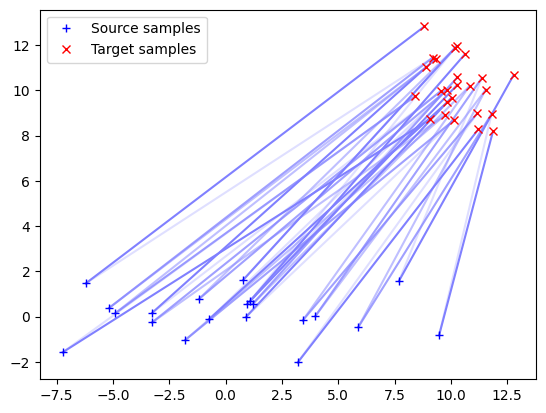

In [10]:
import ot.plot
ot.plot.plot2D_samples_mat(samples_A, samples_B, P, color=[0.5, 0.5, 1])
plt.plot(samples_A[:, 0], samples_A[:, 1], "+b", label="Source samples")
plt.plot(samples_B[:, 0], samples_B[:, 1], "xr", label="Target samples")
plt.legend(loc=0)
plt.show()

In [11]:
import ot.mapping
import matplotlib.pyplot as pl

Xs_new = generate_2d_gaussian_samples(mean_a, std_a, num_samples_a)
Xs = samples_A
Xt = samples_B

# MappingTransport with linear kernel
ot_mapping_linear = ot.da.MappingTransport(
    kernel="linear", mu=1e0, eta=1e-8, bias=True, max_iter=20, verbose=True
)

ot_mapping_linear.fit(Xs=Xs, Xt=Xt)

# for original source samples, transform applies barycentric mapping
transp_Xs_linear = ot_mapping_linear.transform(Xs=Xs)

# for out of source samples, transform applies the linear mapping
transp_Xs_linear_new = ot_mapping_linear.transform(Xs=Xs_new)


# MappingTransport with gaussian kernel
ot_mapping_gaussian = ot.da.MappingTransport(
    kernel="gaussian", eta=1e-5, mu=1e-1, bias=True, sigma=1, max_iter=10, verbose=True
)
ot_mapping_gaussian.fit(Xs=Xs, Xt=Xt)

# for original source samples, transform applies barycentric mapping
transp_Xs_gaussian = ot_mapping_gaussian.transform(Xs=Xs)

# for out of source samples, transform applies the gaussian mapping
transp_Xs_gaussian_new = ot_mapping_gaussian.transform(Xs=Xs_new)

It.  |Loss        |Delta loss
--------------------------------
    0|4.296092e+03|0.000000e+00
    1|4.294166e+03|-4.483190e-04
    2|4.294118e+03|-1.116261e-05
    3|4.294109e+03|-2.125899e-06
It.  |Loss        |Delta loss
--------------------------------
    0|4.290821e+02|0.000000e+00
    1|4.290821e+02|-7.977166e-10


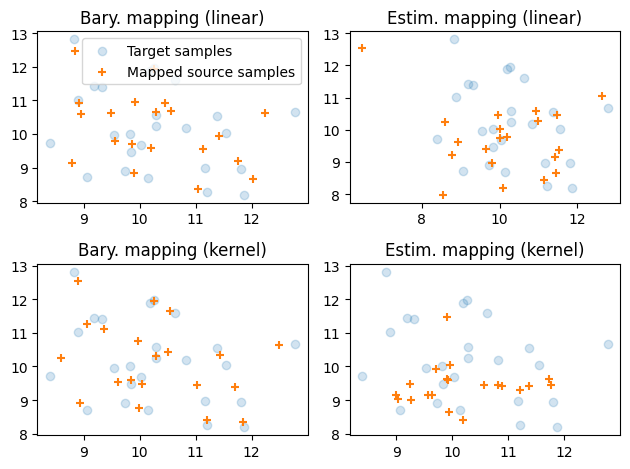

In [12]:
pl.figure(2)
pl.clf()
pl.subplot(2, 2, 1)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_linear[:, 0],
    transp_Xs_linear[:, 1],
    marker="+",
    label="Mapped source samples",
)
pl.title("Bary. mapping (linear)")
pl.legend(loc=0)

pl.subplot(2, 2, 2)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_linear_new[:, 0],
    transp_Xs_linear_new[:, 1],
    marker="+",
    label="Learned mapping",
)
pl.title("Estim. mapping (linear)")

pl.subplot(2, 2, 3)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_gaussian[:, 0],
    transp_Xs_gaussian[:, 1],
    marker="+",
    label="barycentric mapping",
)
pl.title("Bary. mapping (kernel)")

pl.subplot(2, 2, 4)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_gaussian_new[:, 0],
    transp_Xs_gaussian_new[:, 1],
    marker="+",
    label="Learned mapping",
)
pl.title("Estim. mapping (kernel)")
pl.tight_layout()

pl.show()

In [13]:
transported_test_data = ot_mapping_gaussian.transform(Xs=generate_2d_gaussian_samples(mean_a, std_a, num_samples_a))

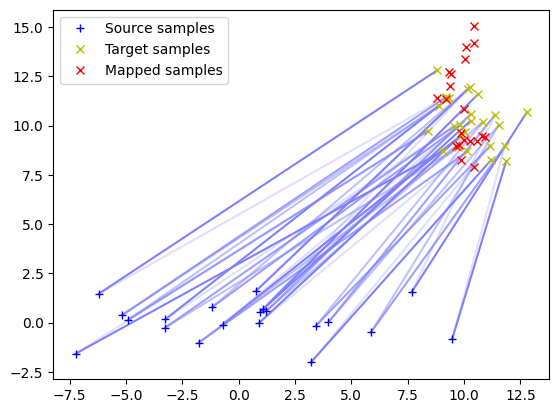

In [14]:
import ot.plot
ot.plot.plot2D_samples_mat(samples_A, samples_B, P, color=[0.5, 0.5, 1])
plt.plot(samples_A[:, 0], samples_A[:, 1], "+b", label="Source samples")
plt.plot(samples_B[:, 0], samples_B[:, 1], "xy", label="Target samples")
plt.plot(transported_test_data[:, 0], transported_test_data[:, 1], "xr", label="Mapped samples")
plt.legend(loc=0)
plt.show()